# Качество выгруженной RBA-модели

Соседний ноутбук `rba_validation` проверяет *методику* оценки - переобучает
модели, сравнивает сплиты, кривые, калибровку, базлайны, дрейф, SHAP. Здесь
другое: характеризуем *качество той самой модели*, что уезжает в прод
(`testdata/model.txt`), на отложенной выборке - той же тройке `holdout.csv` /
`ref_raw.csv`, что сверяет harness паритета на Go.

Сознательно НЕ повторяем первый ноутбук. Только то, чего там нет:
1. Сводные метрики числами: ROC-AUC, Gini, KS, PR-AUC, Brier, ECE.
2. Рабочие точки и матрица ошибок (первый показывает кривые, не точки).
3. Lift по децилям и cumulative gains (там lift - это скаляр PR-AUC/base).
4. Разделимость сырой маржи по классам.
5. Качество по СРЕЗАМ признаков (там дрейф только по времени).
6. Доверительные интервалы на метрики (bootstrap).
7. Анализ ошибок: чем профиль FP и FN отличается от верных решений.

Ноутбук легче первого по вычислениям (модель НЕ обучается, берётся готовая), но
всё ещё грузит весь датасет RBA (~31M строк) ради меток holdout - рассчитан на
машину с большой памятью (см. README, `make data-rba`).

In [1]:
%matplotlib inline
import json
import pathlib
import sys

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# Корень репозитория (ноутбук может запускаться из любого каталога).
ROOT = pathlib.Path.cwd().resolve()
while not (ROOT / "python" / "train.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "python"))
from train import load_rba  # noqa: E402

TD = ROOT / "testdata"
np.random.seed(708)

## 0. Артефакт и восстановление меток holdout

Метки holdout в артефактах не лежат (`holdout.csv` - только признаки). Берём ту
же модель и тот же детерминированный сплит, что в `train.py` (перестановка от
`seed`), и проверяем, что строки совпали с `holdout.csv`, а предсказание
`model.txt` воспроизводит `ref_raw.csv` - тот же инвариант, что доказывает Go.

In [2]:
meta = json.loads((TD / "meta.json").read_text())
seed, n_hold, names = meta["seed"], meta["n_holdout"], meta["feature_names"]
booster = lgb.Booster(model_file=str(TD / "model.txt"))

X_ho = np.loadtxt(TD / "holdout.csv", delimiter=",", skiprows=1)
ref_raw = np.loadtxt(TD / "ref_raw.csv", skiprows=1)

# Полная загрузка ради меток (несколько минут на 31M строк).
X_all, y_all, _ts, names2, codes = load_rba(str(TD / "rba-dataset.csv"), meta["target"])
assert names2 == names, "feature_names разошлись с meta.json"
perm = np.random.default_rng(seed).permutation(len(X_all))
hold_idx = perm[:n_hold]
y_ho = y_all[hold_idx].astype(int)

# Проверка, что восстановленный holdout - это ровно holdout.csv (метки выровнены).
recon = X_all[hold_idx]
diff = np.abs(np.nan_to_num(recon) - np.nan_to_num(X_ho))
tol = 1e-1 + 1e-3 * np.abs(np.nan_to_num(X_ho))
both_nan = np.isnan(recon) & np.isnan(X_ho)
row_ok = ((diff <= tol) | both_nan).all(axis=1)
print(f"выравнивание holdout: {row_ok.mean() * 100:.2f}% строк совпали")
assert row_ok.mean() > 0.999, "сплит не воспроизвёлся - метки не выровнены"

# Скор = сырая маржа; дефолтный порог прода margin>0.
s = booster.predict(X_ho, raw_score=True)
assert np.abs(s - ref_raw).max() < 1e-6, "model.predict разошёлся с ref_raw"
prob = 1.0 / (1.0 + np.exp(-s))
base = float(y_ho.mean())
print(f"holdout={len(y_ho):,} attack={int(y_ho.sum())} base_rate={base:.4f}")
print(f"margin [{s.min():.3f}, {s.max():.3f}]  паритет vs ref_raw maxD={np.abs(s - ref_raw).max():.2e}")

выравнивание holdout: 100.00% строк совпали
holdout=50,000 attack=4963 base_rate=0.0993
margin [-5.152, 2.704]  паритет vs ref_raw maxD=0.00e+00


## 1. Сводные метрики (числами)

Первый ноутбук рисует кривые и reliability diagram; здесь те же качества одной
таблицей чисел, чтобы зафиксировать рабочий снимок. Gini = 2*AUC-1; KS - макс.
разрыв TPR-FPR; Brier и ECE - калибровка (ECE по 10 квантильным корзинам).

In [3]:
def ece(y, p, bins=10):
    edges = np.quantile(p, np.linspace(0, 1, bins + 1))
    e = 0.0
    for k in range(bins):
        lo, hi = edges[k], edges[k + 1]
        m = (p >= lo) & (p <= hi) if k == bins - 1 else (p >= lo) & (p < hi)
        if m.sum():
            e += abs(p[m].mean() - y[m].mean()) * m.sum() / len(p)
    return e


auc = roc_auc_score(y_ho, s)
ap = average_precision_score(y_ho, s)
fpr_c, tpr_c, _ = roc_curve(y_ho, s)
ks = float(np.max(tpr_c - fpr_c))
print(f"ROC-AUC = {auc:.4f}")
print(f"Gini    = {2 * auc - 1:.4f}")
print(f"KS      = {ks:.4f}")
print(f"PR-AUC  = {ap:.4f}   (base rate {base:.4f}, lift {ap / base:.2f})")
print(f"Brier   = {brier_score_loss(y_ho, prob):.5f}")
print(f"ECE     = {ece(y_ho, prob):.5f}")
# Сверка с meta.json (метрики из train.py на том же holdout).
print(f"meta.json: roc_auc={meta['holdout_metrics']['roc_auc']:.4f} "
      f"pr_auc={meta['holdout_metrics']['pr_auc']:.4f}")

ROC-AUC = 0.7032
Gini    = 0.4065
KS      = 0.3040
PR-AUC  = 0.1900   (base rate 0.0993, lift 1.91)
Brier   = 0.08516
ECE     = 0.00381
meta.json: roc_auc=0.7032 pr_auc=0.1900


## 2. Рабочие точки и матрица ошибок

Первый ноутбук показывает precision/recall как кривые и говорит "рабочую точку
выбирают по целевому FPR/recall". Здесь это доведено до конкретики: дефолтный
порог прода (margin>0) и пороги под целевой FPR / recall - с объёмом алертов и
матрицей ошибок.

In [4]:
def at_threshold(t):
    pred = s > t
    tn, fp, fn, tp = confusion_matrix(y_ho, pred, labels=[0, 1]).ravel()
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    fpr = fp / (fp + tn) if fp + tn else 0.0
    return dict(alerts=int(pred.sum()), tp=int(tp), fp=int(fp), fn=int(fn),
                tn=int(tn), precision=prec, recall=rec, f1=f1, fpr=fpr)


points = {
    "margin>0 (дефолт)": 0.0,
    "FPR=1%": float(np.quantile(s[y_ho == 0], 0.99)),
    "FPR=0.1%": float(np.quantile(s[y_ho == 0], 0.999)),
    "recall=20%": float(np.quantile(s[y_ho == 1], 0.80)),
}
print(f"{'точка':18s} {'порог':>7s} {'алертов':>8s} {'prec':>6s} {'recall':>7s} {'F1':>6s} {'FPR':>7s}")
for name, t in points.items():
    m = at_threshold(t)
    print(f"{name:18s} {t:7.3f} {m['alerts']:8d} {m['precision']:6.3f} "
          f"{m['recall']:7.3f} {m['f1']:6.3f} {m['fpr']:7.4f}")

# Матрицы ошибок: дефолт и точка FPR=1%.
for name in ("margin>0 (дефолт)", "FPR=1%"):
    m = at_threshold(points[name])
    print(f"\n{name}:")
    print(f"   benign:  TN={m['tn']:6d}  FP={m['fp']:5d}")
    print(f"   attack:  FN={m['fn']:6d}  TP={m['tp']:5d}")

точка                порог  алертов   prec  recall     F1     FPR
margin>0 (дефолт)    0.000       20  0.900   0.004  0.007  0.0000
FPR=1%              -1.136      638  0.293   0.038  0.067  0.0100
FPR=0.1%            -0.890       89  0.483   0.009  0.017  0.0010
recall=20%          -1.557     4652  0.213   0.200  0.207  0.0812

margin>0 (дефолт):
   benign:  TN= 45035  FP=    2
   attack:  FN=  4945  TP=   18

FPR=1%:
   benign:  TN= 44586  FP=  451
   attack:  FN=  4776  TP=  187


### Подбор порога под целевую метрику

Обратная задача к таблице выше: задаём цель (recall / FPR / precision / бюджет
алертов) - получаем порог `margin`, который ставится в сервис флагом `-threshold`,
и полную рабочую точку при нём. Берём минимальный порог, удовлетворяющий цели,
то есть максимум охвата при ограничении.

In [5]:
def select_threshold(metric, target):
    neg, pos = s[y_ho == 0], s[y_ho == 1]
    if metric == "recall":        # поймать не меньше target атак
        t = float(np.quantile(pos, 1 - target))
    elif metric == "fpr":         # не больше target ложных среди benign
        t = float(np.quantile(neg, 1 - target))
    elif metric == "alerts":      # ровно top-N сессий по скору
        t = float(np.sort(s)[::-1][min(int(target), len(s) - 1)])
    elif metric == "precision":   # мин. порог с precision >= target (макс. recall при ограничении)
        prec, _rec, thr = precision_recall_curve(y_ho, s)
        ok = np.where(prec[:-1] >= target)[0]
        t = float(thr[ok[0]]) if len(ok) else float(s.max())
    else:
        raise ValueError(metric)
    return t, at_threshold(t)


targets = [("recall", 0.50, "поймать >=50% атак"),
           ("fpr", 0.005, "<=0.5% ложных среди benign"),
           ("precision", 0.30, "precision >=30%"),
           ("alerts", 500, "бюджет 500 алертов")]
print(f"{'цель':28s} {'-threshold':>11s} {'alerts':>7s} {'prec':>6s} {'recall':>7s} {'FPR':>7s}")
for metric, target, desc in targets:
    t, m = select_threshold(metric, target)
    print(f"{desc:28s} {t:11.3f} {m['alerts']:7d} {m['precision']:6.3f} "
          f"{m['recall']:7.3f} {m['fpr']:7.4f}")

цель                          -threshold  alerts   prec  recall     FPR
поймать >=50% атак                -1.860   13932  0.178   0.500  0.2543
<=0.5% ложных среди benign        -1.077     329  0.328   0.022  0.0049
precision >=30%                   -1.096     402  0.301   0.024  0.0062
бюджет 500 алертов                -1.114     491  0.289   0.029  0.0077


## 3. Lift по децилям и cumulative gains

Сортируем holdout по убыванию скора, режем на 10 равных групп. Lift децили =
(доля атак в децили)/(base rate). Cumulative gain = какая доля всех атак собрана
в верхних X% выборки. Это операционный взгляд "сколько ловим, разбирая top-N".

дециль    доля+   lift  кум.recall
      1   0.212   2.14       0.214
      2   0.171   1.73       0.386
      3   0.140   1.41       0.527
      4   0.130   1.31       0.658
      5   0.112   1.13       0.771
      6   0.088   0.89       0.860
      7   0.072   0.72       0.932
      8   0.039   0.39       0.972
      9   0.019   0.19       0.991
     10   0.009   0.09       1.000


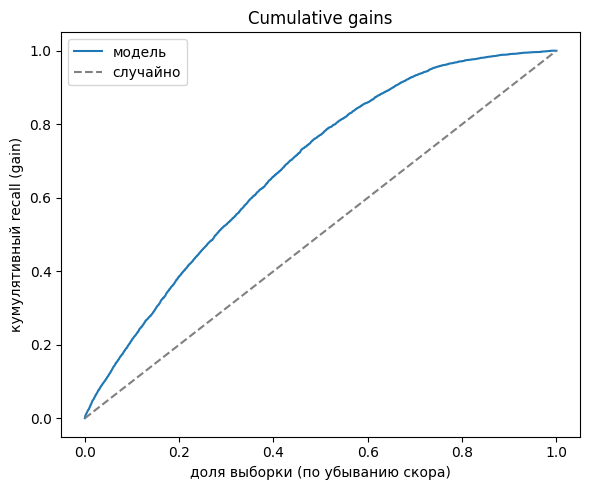

In [6]:
order = np.argsort(-s)
y_sorted = y_ho[order]
n, P = len(y_ho), int(y_ho.sum())
print(f"{'дециль':7s} {'доля+':>7s} {'lift':>6s} {'кум.recall':>11s}")
cum = 0
for d in range(10):
    seg = y_sorted[d * n // 10:(d + 1) * n // 10]
    pos = int(seg.sum())
    cum += pos
    print(f"{d + 1:7d} {pos / len(seg):7.3f} {(pos / len(seg)) / base:6.2f} {cum / P:11.3f}")

frac = np.arange(1, n + 1) / n
plt.figure(figsize=(6, 5))
plt.plot(frac, np.cumsum(y_sorted) / P, label="модель")
plt.plot([0, 1], [0, 1], "--", c="gray", label="случайно")
plt.xlabel("доля выборки (по убыванию скора)")
plt.ylabel("кумулятивный recall (gain)")
plt.title("Cumulative gains")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Разделимость скоров по классам

Распределение сырой маржи отдельно для benign и attack. Чем дальше разнесены
моды, тем лучше ранжирование; пересечение в районе порога - зона ошибок.

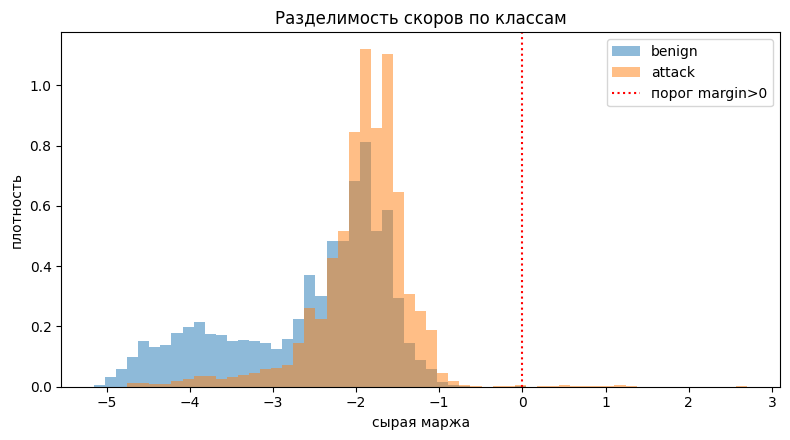

In [7]:
plt.figure(figsize=(8, 4.5))
bins = np.linspace(s.min(), s.max(), 60)
plt.hist(s[y_ho == 0], bins=bins, density=True, alpha=0.5, label="benign")
plt.hist(s[y_ho == 1], bins=bins, density=True, alpha=0.5, label="attack")
plt.axvline(0, c="r", ls=":", label="порог margin>0")
plt.xlabel("сырая маржа")
plt.ylabel("плотность")
plt.title("Разделимость скоров по классам")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Качество по срезам признаков

Первый ноутбук смотрит дрейф по ВРЕМЕНИ; здесь срезы по ПРИЗНАКАМ - где модель
сильна, где слепа. На срез: размер, base rate, ROC-AUC и precision/recall при
дефолтном пороге.

In [8]:
idx = {nm: i for i, nm in enumerate(names)}


def auc_safe(yy, ss):
    return roc_auc_score(yy, ss) if 0 < yy.sum() < len(yy) else float("nan")


def slice_report(mask, label):
    yy, ss = y_ho[mask], s[mask]
    pred = ss > 0
    print(f"{label:22s} n={int(mask.sum()):6d} base={yy.mean():.4f} "
          f"AUC={auc_safe(yy, ss):.4f} P@0={precision_score(yy, pred, zero_division=0):.3f} "
          f"R@0={recall_score(yy, pred, zero_division=0):.3f}")


print("=== новизна устройства ===")
slice_report(X_ho[:, idx["is_new_device"]] == 1, "новое устройство")
slice_report(X_ho[:, idx["is_new_device"]] == 0, "знакомое")
print("=== новизна страны ===")
slice_report(X_ho[:, idx["is_new_country"]] == 1, "новая страна")
slice_report(X_ho[:, idx["is_new_country"]] == 0, "знакомая")
print("=== час входа ===")
h = X_ho[:, idx["hour"]]
slice_report((h >= 0) & (h < 6), "ночь 0-6")
slice_report((h >= 6) & (h < 18), "день 6-18")
slice_report(h >= 18, "вечер 18-24")
print("=== история пользователя ===")
npl = X_ho[:, idx["n_prior_logins"]]
slice_report(npl == 0, "первый вход")
slice_report((npl >= 1) & (npl <= 10), "1-10 входов")
slice_report(npl > 10, ">10 входов")

=== новизна устройства ===
новое устройство       n=  8383 base=0.1155 AUC=0.6955 P@0=0.000 R@0=0.000
знакомое               n= 41617 base=0.0960 AUC=0.7041 P@0=0.900 R@0=0.005
=== новизна страны ===
новая страна           n=  7067 base=0.1351 AUC=0.6469 P@0=1.000 R@0=0.004
знакомая               n= 42933 base=0.0934 AUC=0.7102 P@0=0.875 R@0=0.003
=== час входа ===
ночь 0-6               n=  6880 base=0.1503 AUC=0.6589 P@0=0.867 R@0=0.013
день 6-18              n= 32694 base=0.1024 AUC=0.6827 P@0=1.000 R@0=0.001
вечер 18-24            n= 10426 base=0.0557 AUC=0.6986 P@0=1.000 R@0=0.002
=== история пользователя ===
первый вход            n=  6931 base=0.1355 AUC=0.6438 P@0=0.000 R@0=0.000
1-10 входов            n= 15585 base=0.0749 AUC=0.7772 P@0=1.000 R@0=0.005
>10 входов             n= 27484 base=0.1039 AUC=0.6650 P@0=0.857 R@0=0.004


## 6. Доверительные интервалы (bootstrap)

Метрики на одном holdout - точечные оценки. Bootstrap (ресэмпл с возвратом)
даёт 95% интервал: видно, насколько ROC-AUC/PR-AUC устойчивы, а не "повезло".

In [9]:
rng = np.random.default_rng(seed)
B = 300
aucs, aps = np.empty(B), np.empty(B)
for b in range(B):
    i = rng.integers(0, len(y_ho), len(y_ho))
    aucs[b] = roc_auc_score(y_ho[i], s[i])
    aps[b] = average_precision_score(y_ho[i], s[i])
for label, arr in (("ROC-AUC", aucs), ("PR-AUC", aps)):
    lo, md, hi = np.quantile(arr, [0.025, 0.5, 0.975])
    print(f"{label}: {md:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")

ROC-AUC: 0.7034  95% CI [0.6973, 0.7097]
PR-AUC: 0.1897  95% CI [0.1820, 0.1982]


## 7. На чём модель путается

Не медианы ради медиан, а ответ: где у модели нет сигнала. Признаки новизны
(страна/город/ASN/ОС/браузер/устройство) - главный рычаг RBA. Гипотеза: модель
ПРОПУСКАЕТ атаки без новизны (выглядят как обычный вход) и ЛОЖНО срабатывает на
доброкачественных входах С новизной (переезд, новый телефон).

In [10]:
pred = s > 0
tp, fp, fn = pred & (y_ho == 1), pred & (y_ho == 0), ~pred & (y_ho == 1)
novelty = [idx[n] for n in ("is_new_country", "is_new_city", "is_new_asn",
                            "is_new_os", "is_new_browser", "is_new_device")]
nov = np.nan_to_num(X_ho[:, novelty])
no_novelty = (nov == 0).all(axis=1)   # ни один сигнал новизны не сработал
any_novelty = (nov == 1).any(axis=1)

# Зона перекрытия у порога: где скоры атак и benign смешаны.
band = np.abs(s) < 0.5
print(f"зона |margin|<0.5: {band.mean() * 100:.1f}% выборки, атак в ней "
      f"{y_ho[band].mean() * 100:.1f}% (база {base * 100:.1f}%)")

# FN: пропущенные атаки выглядят как обычный вход (нет сигналов новизны).
print(f"\nFN пропущено: {int(fn.sum())} из {int(y_ho.sum())} атак "
      f"({fn.sum() / y_ho.sum() * 100:.1f}%)")
print(f"  без новизны: {no_novelty[fn].mean() * 100:.1f}% "
      f"(среди всех атак: {no_novelty[y_ho == 1].mean() * 100:.1f}%)")
print(f"  медиана прошлых входов: {np.nanmedian(X_ho[fn][:, idx['n_prior_logins']]):.0f}")

# FP: ложные срабатывания вызваны новизной у доброкачественных.
print(f"\nFP ложных: {int(fp.sum())}")
print(f"  с новизной: {any_novelty[fp].mean() * 100:.1f}% "
      f"(среди всех benign: {any_novelty[y_ho == 0].mean() * 100:.1f}%)")

# Контекст: медианы признаков по группам.
print()
groups = {"TP пойманные": tp, "FP ложные": fp, "FN пропущенные": fn}
show = ["n_prior_logins", "secs_since_last", "is_new_device", "is_new_country", "hour", "rtt_ms"]
print(f"{'признак':16s}" + "".join(f"{g:>16s}" for g in groups))
for nm in show:
    row = f"{nm:16s}"
    for g, mask in groups.items():
        col = X_ho[mask][:, idx[nm]]
        med = np.nanmedian(col) if np.isfinite(col).any() else float("nan")
        row += f"{med:16.3g}"
    print(row)

зона |margin|<0.5: 0.0% выборки, атак в ней 59.1% (база 9.9%)

FN пропущено: 4945 из 4963 атак (99.6%)
  без новизны: 75.2% (среди всех атак: 75.2%)
  медиана прошлых входов: 993693

FP ложных: 2
  с новизной: 0.0% (среди всех benign: 33.1%)

признак             TP пойманные       FP ложные  FN пропущенные
n_prior_logins          3.31e+03        1.06e+07        9.94e+05
secs_since_last            0.931           0.662            1.64
is_new_device                  0               0               0
is_new_country                 0               0               0
hour                           4             2.5              11
rtt_ms                       384             nan             576


## 8. SHAP-объяснения на фродовых сессиях

Первый ноутбук даёт ГЛОБАЛЬНЫЙ beeswarm; здесь - ЛОКАЛЬНЫЕ per-decision
объяснения тем же нативным pred_contrib, что в проде отдаёт `/explain`. Берём
`ref_contrib.csv` (выгруженный SHAP) на конкретных сессиях: пойманной атаке (TP),
пропущенной (FN) и ложном срабатывании (FP). Вклад >0 толкает к атаке;
sum(вклады)+base == маржа (тот же инвариант, что сверяет Go).

In [11]:
contrib = np.loadtxt(TD / "ref_contrib.csv", delimiter=",", skiprows=1)  # (n, nf+1)
nf = len(names)
assert np.abs(contrib.sum(axis=1) - s).max() < 1e-6, "sum(contrib) != margin"


def explain_row(i, title):
    c = contrib[i, :nf]
    print(f"\n{title}: margin={s[i]:.3f} P(attack)={prob[i]:.3f} "
          f"решение={'decline' if s[i] > 0 else 'approve'} факт={'attack' if y_ho[i] else 'benign'}")
    for j in np.argsort(-np.abs(c))[:5]:
        nm = names[j]
        print(f"   {codes[nm]['code']:8s} {nm:18s} value={X_ho[i, j]:10.4g} "
              f"вклад={c[j]:+.3f} ({'к атаке' if c[j] > 0 else 'от атаки'})")


atk, ben = np.where(y_ho == 1)[0], np.where(y_ho == 0)[0]
i_tp = atk[np.argmax(s[atk])]   # пойманная атака: макс. маржа
i_fn = atk[np.argmin(s[atk])]   # пропущенная: мин. маржа
i_fp = ben[np.argmax(s[ben])]   # ложное срабатывание: макс. маржа среди benign
explain_row(i_tp, "TP пойманная атака")
explain_row(i_fn, "FN пропущенная атака")
explain_row(i_fp, "FP ложное срабатывание")


TP пойманная атака: margin=2.704 P(attack)=0.937 решение=decline факт=attack
   NPRIOR   n_prior_logins     value=      1188 вклад=+2.430 (к атаке)
   GAP      secs_since_last    value=     809.7 вклад=+2.176 (к атаке)
   RTT      rtt_ms             value=       384 вклад=-0.592 (от атаки)
   HOUR     hour               value=         3 вклад=+0.592 (к атаке)
   LOGINOK  login_successful   value=         1 вклад=+0.331 (к атаке)

FN пропущенная атака: margin=-4.745 P(attack)=0.009 решение=approve факт=attack
   RTT      rtt_ms             value=       625 вклад=-1.314 (от атаки)
   GAP      secs_since_last    value= 2.617e+06 вклад=-0.538 (от атаки)
   NEWCITY  is_new_city        value=         1 вклад=-0.280 (от атаки)
   LOGINOK  login_successful   value=         1 вклад=-0.163 (от атаки)
   NEWASN   is_new_asn         value=         0 вклад=-0.111 (от атаки)

FP ложное срабатывание: margin=0.295 P(attack)=0.573 решение=decline факт=benign
   HOUR     hour               value=      

Локальные SHAP-бары тех же сессий: какие признаки и куда двигают маржу (красное -
к атаке, синее - от атаки).

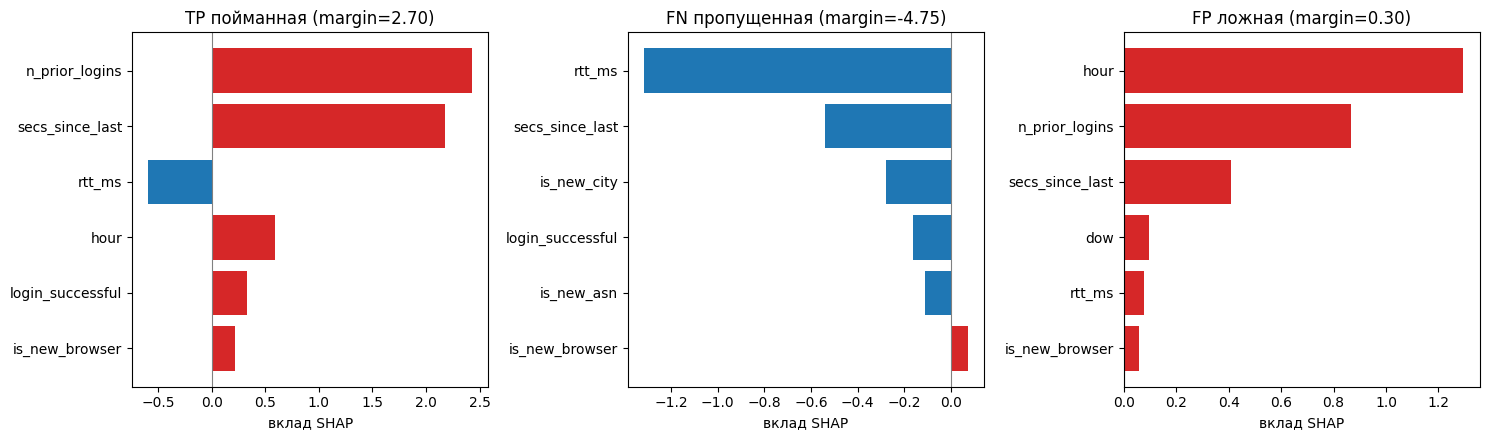

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, i, title in zip(axes, [i_tp, i_fn, i_fp],
                        ["TP пойманная", "FN пропущенная", "FP ложная"]):
    c = contrib[i, :nf]
    o = np.argsort(np.abs(c))[-6:]
    ax.barh(range(len(o)), c[o], color=["tab:red" if v > 0 else "tab:blue" for v in c[o]])
    ax.set_yticks(range(len(o)))
    ax.set_yticklabels([names[k] for k in o])
    ax.axvline(0, c="gray", lw=0.8)
    ax.set_title(f"{title} (margin={s[i]:.2f})")
    ax.set_xlabel("вклад SHAP")
plt.tight_layout()
plt.show()

## Итог

- Сводные метрики (AUC/Gini/KS/PR-AUC/Brier/ECE) воспроизводят `meta.json` - это
  качество ИМЕННО выгруженной `model.txt`, а не переобученной копии.
- Рабочие точки, матрица ошибок и подбор порога под целевую метрику
  (recall/FPR/precision/бюджет) дают конкретный `-threshold` для прода.
- Lift/gain и срезы показывают, где сигнал концентрируется (верхние децили,
  новизна, первые входы), а bootstrap-CI - что метрики устойчивы, не случайны.
- На чём путается: пропускает атаки без сигналов новизны (выглядят как обычный
  вход) и ложно срабатывает на доброкачественных входах с новизной.
- SHAP на фродовых сессиях - тот же pred_contrib, что в проде даёт /explain:
  видно per-decision, какие признаки двинули решение по каждой атаке.